In [1]:
from pathlib import Path
import pandas as pd

matched_pairs = pd.read_csv('matched_pairs.csv')
matched_pairs['date'] = pd.to_datetime(matched_pairs['date'])

In [2]:
sector_abbrev = {
    'Basic Materials':         'BM',
    'Consumer Cyclical':       'CC',
    'Consumer Defensive':      'CD',
    'Communication Services':  'CS',
    'Energy':                  'EN',
    'Financial Services':      'FS',
    'Healthcare':              'HC',
    'Industrials':             'IN',
    'Real Estate':             'RE',
    'Technology':              'TE',
    'Utilities':               'UT'
}

In [3]:
dfs = [] # This will hold nested DataFrames (382 in the end)

# Read one row of matched_pairs at a time 
for pair_id, pair in matched_pairs.iterrows():
    
    sector_code = sector_abbrev[pair['sector']]
    date_str = pair['date'].strftime('%Y-%m-%d')

    # Access data .csv for treated stock, then control
    for ticker, role, treated in [(pair['treated'], 'T', 1), (pair['control'], 'C', 0)]:
        
        filepath = f'Data/{ticker}_{role}_{sector_code}_{date_str}.csv'
        df = pd.read_csv(filepath)
        
        df['date'] = pd.to_datetime(df['date'])
        df['pair_id'] = pair_id
        df['ticker'] = ticker
        df['treated'] = treated
        df['event_date'] = pair['date']
        df['sector'] = pair['sector']
        dfs.append(df)

# Form into panel
panel = pd.concat(dfs)
panel = panel[['pair_id', 'ticker', 'treated', 'event_date', 'sector', 'adj_close', 'volume',
               'date', 'treatment_rel', 'log_return', 'log_volume_change', 'log_volatility']]
panel['treatment_rel'] = panel['treatment_rel'].astype(int)
panel['abs_log_return'] = panel['log_return'].abs()

In [4]:
observables = ['log_return', 'log_volume_change', 'log_volatility', 'abs_log_return']

# Re-format panel by pivoting on pair ID and event date (consolidates two rows into one) 
pivot = panel.pivot(
    index=['pair_id', 'event_date', 'sector', 'date', 'treatment_rel'],
    columns='treated',
    values=observables
).reset_index()

# Differencing (DeltaY)
for x in observables:
    pivot[f'd_{x}'] = pivot[(x,1)] - pivot[(x,0)]

pivot.drop(columns=observables, level=0, inplace=True)
pivot.columns = pivot.columns.get_level_values(0)

In [5]:
import statsmodels.formula.api as smf

# Function written to not unnecessarily repeat virtually the same code across 6 regressions
def regress_DiD(dep_var, ref_date, window, yes_marker, ytext):

    # See paper for regression specification explanation
    model = smf.ols(
        f'd_{dep_var} ~ C(pair_id) + C(treatment_rel, Treatment(reference={ref_date}))',
        data=pivot
    ).fit(cov_type='cluster', cov_kwds={'groups': pivot['pair_id']})

    results = pd.DataFrame({
        'coef': model.params,
        'se': model.bse,
        'pvalue': model.pvalues,
        'upper': model.conf_int()[1],
        'lower': model.conf_int()[0],
    })
    
    results = results[results.index.str.contains('treatment_rel')]
    results['treatment_rel'] = results.index.str.extract(r'\[T\.(-?\d+)\]', expand=False).astype(int)
    results.sort_values('treatment_rel', inplace=True)

    plot_results = results.query(f'-{window} <= treatment_rel <= {window}')
    plt.figure(figsize=(12, 6))
    
    if yes_marker:
        plt.plot(plot_results['treatment_rel'], plot_results['coef'], marker='o')
    else:
        plt.plot(plot_results['treatment_rel'], plot_results['coef'])
    
    plt.fill_between(plot_results['treatment_rel'], plot_results['lower'], plot_results['upper'], alpha=0.3)
    plt.axhline(0, linestyle='--', linewidth=1)
    plt.axvline(0, linestyle='--', linewidth=1)
    plt.xlabel('Trading days relative to inclusion')
    plt.ylabel(ytext)
    plt.show()

    return plot_results

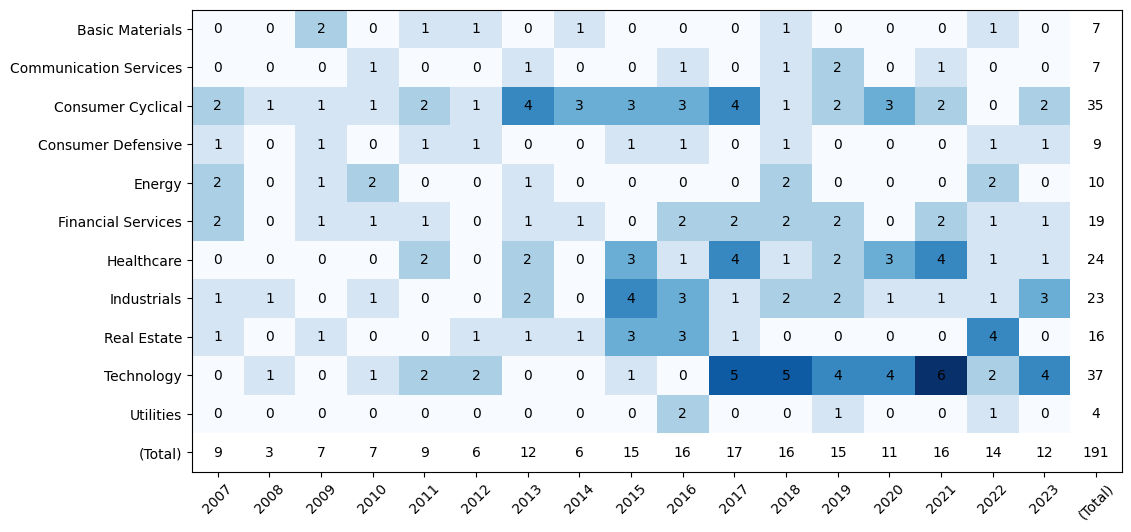

In [6]:
import numpy as np
import matplotlib.pyplot as plt

matched_pairs['year'] = matched_pairs['date'].dt.year
table = pd.crosstab(matched_pairs['sector'], matched_pairs['year'])

display = table.copy()
display['(Total)'] = table.sum(axis=1)
display.loc['(Total)'] = display.sum(axis=0)

# Do not color the total row and column
colors = display.copy()
colors.loc['(Total)', :] = np.nan
colors.loc[:, '(Total)'] = np.nan

fig, ax = plt.subplots(figsize=(12, 6))
im = ax.imshow(colors, aspect='auto', cmap='Blues')

ax.set_xticks(range(len(display.columns)))
ax.set_xticklabels(display.columns, rotation=45)

ax.set_yticks(range(len(display.index)))
ax.set_yticklabels(display.index)

for i in range(len(display.index)):
    for j in range(len(display.columns)):
        ax.text(j, i, display.iloc[i, j], ha='center', va='center')

plt.show()

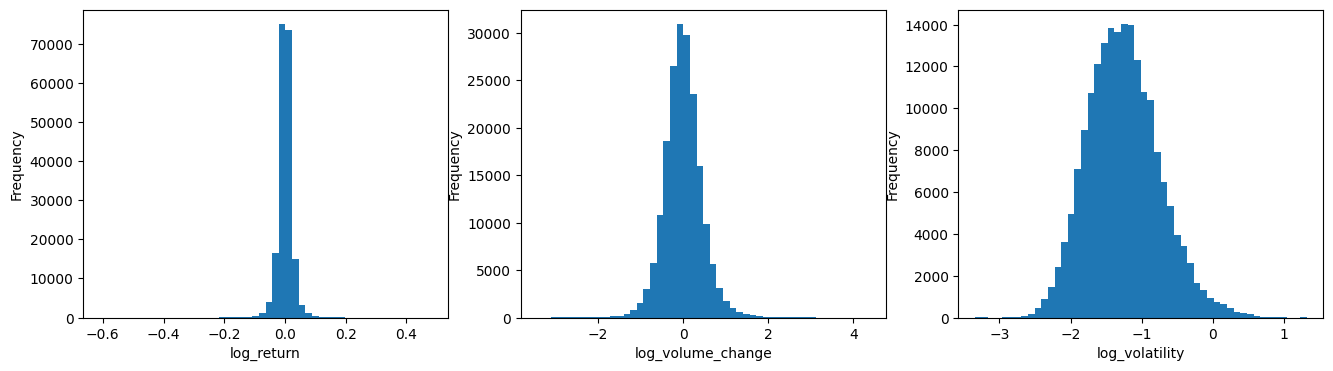

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

for ax, var in zip(axes, observables):
    ax.hist(panel[var], bins=50)
    ax.set_xlabel(var)
    ax.set_ylabel('Frequency')

plt.show()

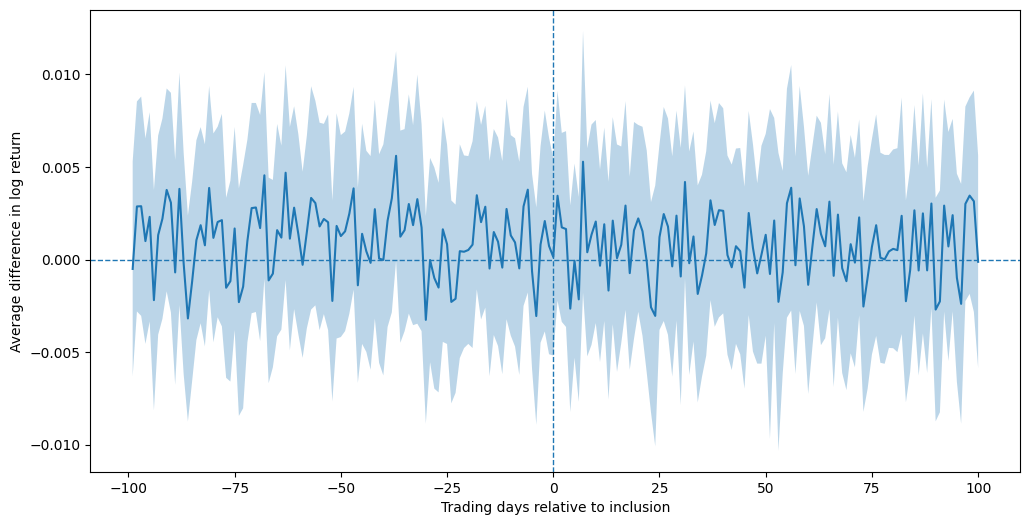

In [8]:
results1 = regress_DiD('log_return', -100, 100, False, 'Average difference in log return')

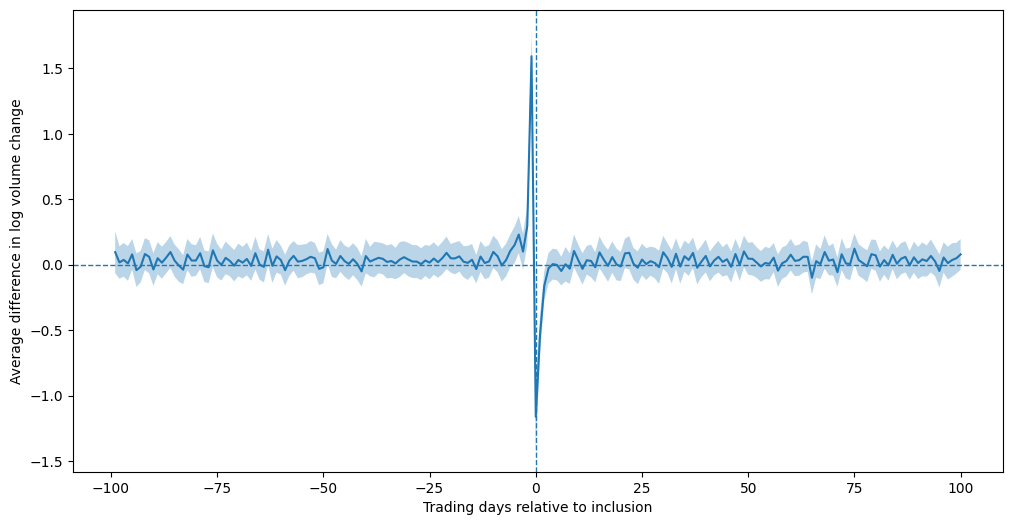

In [9]:
results2 = regress_DiD('log_volume_change', -100, 100, False, 'Average difference in log volume change')

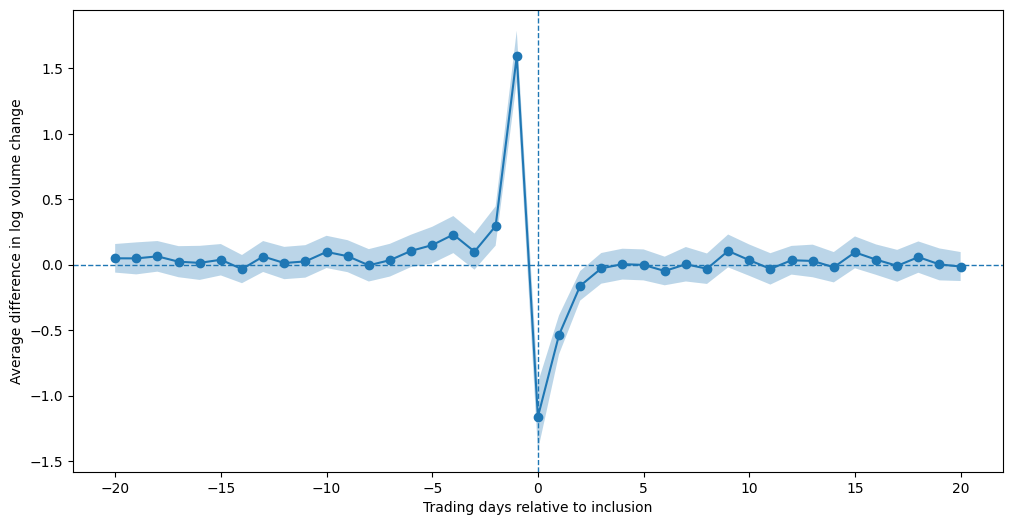

In [10]:
results3 = regress_DiD('log_volume_change', -100, 20, True, 'Average difference in log volume change')

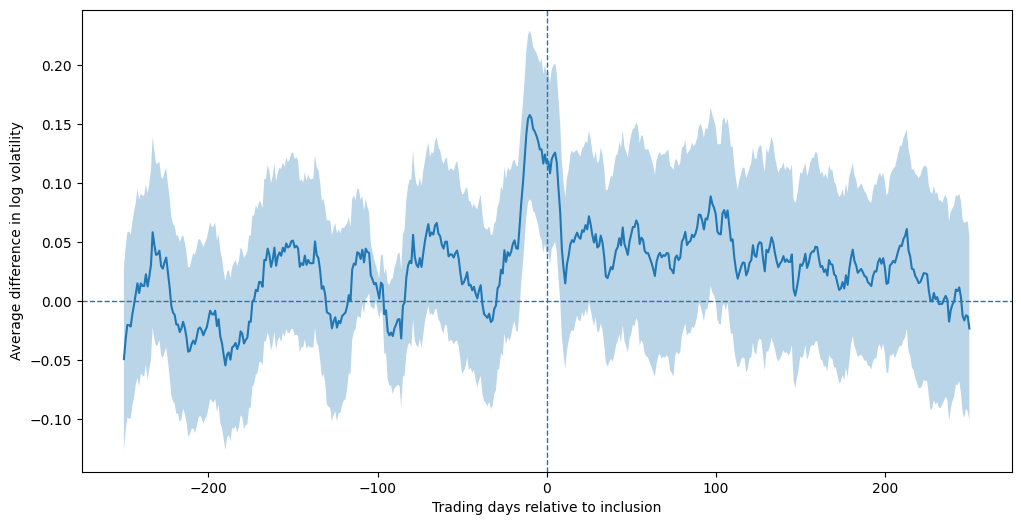

In [11]:
results4 = regress_DiD('log_volatility', -100, 250, False, 'Average difference in log volatility')

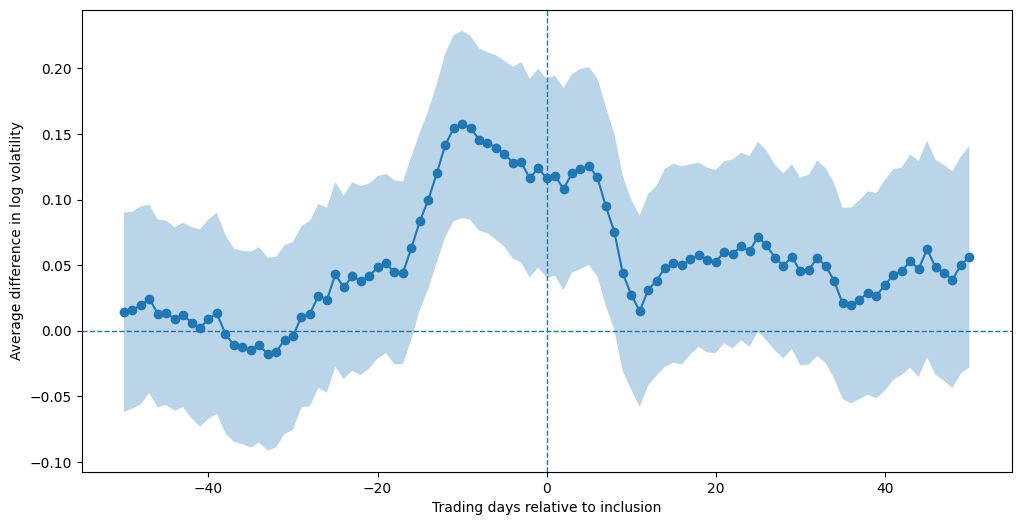

In [12]:
results5 = regress_DiD('log_volatility', -100, 50, True, 'Average difference in log volatility')

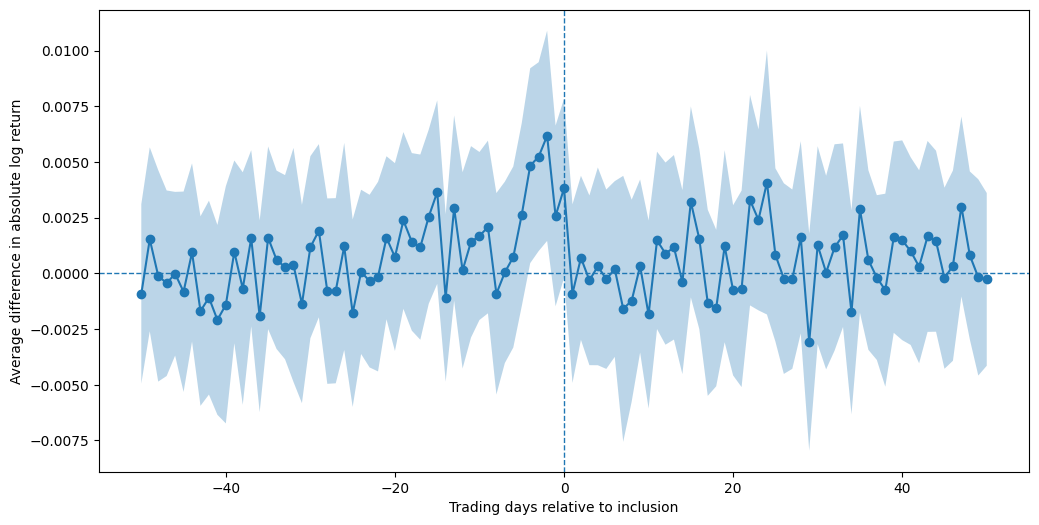

In [13]:
results6 = regress_DiD('abs_log_return', -100, 50, True, 'Average difference in absolute log return')

In [14]:
results6.query(f'-10 <= treatment_rel <= 10')

,coef,se,pvalue,upper,lower,treatment_rel
"C(treatment_rel, Treatment(reference=-100))[T.-10]",0.001680,0.001925,0.382710,0.005452,-0.002092,-10
"C(treatment_rel, Treatment(reference=-100))[T.-9]",0.002083,0.001978,0.292230,0.005960,-0.001794,-9
"C(treatment_rel, Treatment(reference=-100))[T.-8]",-0.000916,0.002308,0.691618,0.003608,-0.005439,-8
"C(treatment_rel, Treatment(reference=-100))[T.-7]",0.000046,0.002078,0.982281,0.004119,-0.004027,-7
"C(treatment_rel, Treatment(reference=-100))[T.-6]",0.000736,0.002074,0.722657,0.004802,-0.003329,-6
"C(treatment_rel, Treatment(reference=-100))[T.-5]",0.002638,0.002098,0.208573,0.006750,-0.001474,-5
"C(treatment_rel, Treatment(reference=-100))[T.-4]",0.004836,0.002232,0.030274,0.009211,0.000461,-4
"C(treatment_rel, Treatment(reference=-100))[T.-3]",0.005243,0.002164,0.015391,0.009484,0.001002,-3
"C(treatment_rel, Treatment(reference=-100))[T.-2]",0.006178,0.002408,0.010297,0.010898,0.001459,-2
"C(treatment_rel, Treatment(reference=-100))[T.-1]",0.002582,0.002070,0.212447,0.006640,-0.001476,-1
